# Kaggle Deep Learning Baselines

This notebook trains and evaluates two deep learning models, which are TextCNN and BiLSTM, on the processed Kaggle dataset using the PyTorch framework. Both models use a shared tokenisation and batching pipeline and are evaluated using the same metrics schema as the other project baselines for direct comparison.

> **Note on framework choice:** The MeAJOR deep learning notebook uses Keras/TensorFlow, while this Kaggle notebook uses PyTorch. PyTorch is retained here because the original Kaggle implementation depends on custom `Dataset` and `DataLoader` objects together with `pack_padded_sequence` for the BiLSTM. The presentation style is aligned to MeAJOR, but the Kaggle training pipeline and model code remain unchanged.

## 1. Import Libraries

All libraries needed for loading data, building and training deep learning models, and evaluating and saving results are imported here.

In [1]:
import os
import time
import random
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore")

## 2. Load Processed Data

The train and test Parquet files produced by `kaggle_preparation.ipynb` are loaded here. These contain the cleaned `text`, `label`, and `source` columns used throughout the deep learning experiments.

In [2]:
SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

data_dir = Path("../data/processed/kaggle/")
glove_path = Path("../data/glove/glove.6B.100d.txt")
results_dir = Path("../results/")
results_dir.mkdir(parents=True, exist_ok=True)

EMBED_DIM = 100
MAX_LEN = 200
VOCAB_SIZE = 20000
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
NUM_EPOCHS = 10
DROPOUT = 0.5
CNN_FILTER_SIZES = [2, 3, 4]
CNN_NUM_FILTERS = 128
LSTM_HIDDEN = 128
LSTM_LAYERS = 2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_df = pd.read_parquet(data_dir / "kaggle_train_60.parquet")
test_df = pd.read_parquet(data_dir / "kaggle_test_40.parquet")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Device:", DEVICE)

Train shape: (1435, 3)
Test shape: (957, 3)
Device: cpu


## 3. Verify Loaded Data

A quick check to confirm the data loaded correctly, the label distribution is preserved, and sample rows look as expected before modelling begins.

In [3]:
display(train_df.head(3))
print()

print("Train label distribution:")
print(train_df["label"].value_counts())
print()
print("Test label distribution:")
print(test_df["label"].value_counts())
print()
print("Train source breakdown:")
print(train_df["source"].value_counts())
print()
print("Test source breakdown:")
print(test_df["source"].value_counts())

,text,label,source
0,Rachel Thompson COVID-19 Vaccination Team,1,llm-generated
1,Notification: jose@monkey.org Dear jose To c...,1,human-generated
2,ActiveState evaluation license for Komodo IDE ...,0,human-generated



Train label distribution:
label
0    1034
1     401
Name: count, dtype: int64

Test label distribution:
label
0    690
1    267
Name: count, dtype: int64

Train source breakdown:
source
human-generated    762
llm-generated      673
Name: count, dtype: int64

Test source breakdown:
source
llm-generated      489
human-generated    468
Name: count, dtype: int64


## 4. Prepare Features and Labels

The text and label fields are separated for both splits, and the tokenisation, vocabulary, and batching setup are created from the Kaggle training data only to avoid leakage.

In [4]:
def simple_tokenise(text):
    return str(text).split()

X_train = train_df["text"].astype(str)
y_train = train_df["label"].values
X_test = test_df["text"].astype(str)
y_test = test_df["label"].values

print(f"Null values in X_train: {train_df['text'].isna().sum()}")
print(f"Null values in X_test:  {test_df['text'].isna().sum()}")
print(f"X_train: {len(X_train)} samples")
print(f"X_test:  {len(X_test)} samples")

all_tokens = []
for text in train_df["text"]:
    all_tokens.extend(simple_tokenise(text))

token_counts = Counter(all_tokens)
most_common = [tok for tok, _ in token_counts.most_common(VOCAB_SIZE - 2)]
vocab = {"<PAD>": 0, "<UNK>": 1}
for tok in most_common:
    vocab[tok] = len(vocab)

print("Vocabulary size:", len(vocab))

def encode(text, max_len):
    tokens = simple_tokenise(text)[:max_len]
    ids = [vocab.get(t, vocab["<UNK>"]) for t in tokens]
    ids += [0] * (max_len - len(ids))
    return ids, min(len(tokens), max_len)

class EmailDataset(Dataset):
    def __init__(self, df, max_len):
        self.labels = df["label"].values
        self.encodings = []
        self.lengths = []
        for text in df["text"]:
            ids, length = encode(text, max_len)
            self.encodings.append(ids)
            self.lengths.append(length)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.encodings[idx], dtype=torch.long),
            torch.tensor(self.lengths[idx], dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.float),
        )

val_sub = train_df.sample(frac=0.1, random_state=SEED)
train_sub = train_df.drop(val_sub.index).reset_index(drop=True)
val_sub = val_sub.reset_index(drop=True)

train_dataset = EmailDataset(train_sub, MAX_LEN)
val_dataset = EmailDataset(val_sub, MAX_LEN)
test_dataset = EmailDataset(test_df, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Null values in X_train: 0
Null values in X_test:  0
X_train: 1435 samples
X_test:  957 samples
Vocabulary size: 20000
Train batches: 41
Val batches: 5
Test batches: 30


In [5]:
def train_epoch(model, loader, optimiser, criterion, device):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for sequences, lengths, labels in loader:
        sequences, lengths, labels = sequences.to(device), lengths.to(device), labels.to(device)
        optimiser.zero_grad()
        logits = model(sequences, lengths)
        loss = criterion(logits, labels)
        loss.backward()
        optimiser.step()

        total_loss += loss.item() * len(labels)
        preds = (torch.sigmoid(logits) >= 0.5).long().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().long().numpy())

    train_acc = accuracy_score(all_labels, all_preds)
    return total_loss / len(loader.dataset), train_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for sequences, lengths, labels in loader:
            sequences, lengths, labels = sequences.to(device), lengths.to(device), labels.to(device)
            logits = model(sequences, lengths)
            loss = criterion(logits, labels)
            total_loss += loss.item() * len(labels)
            preds = (torch.sigmoid(logits) >= 0.5).long().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().long().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    return avg_loss, acc, prec, rec, f1, fpr, all_labels, all_preds


def measure_inference_time(model, loader, device, n_runs=3):
    model.eval()
    all_seqs, all_lens = [], []
    for sequences, lengths, _ in loader:
        all_seqs.append(sequences)
        all_lens.append(lengths)
    all_seqs = torch.cat(all_seqs, dim=0).to(device)
    all_lens = torch.cat(all_lens, dim=0).to(device)

    times = []
    with torch.no_grad():
        for _ in range(n_runs):
            start = time.perf_counter()
            _ = model(all_seqs, all_lens)
            end = time.perf_counter()
            times.append((end - start) * 1000)
    return round(np.mean(times) / len(all_seqs), 4)


def count_params(module):
    return sum(p.numel() for p in module.parameters())


def count_trainable_params(module):
    return sum(p.numel() for p in module.parameters() if p.requires_grad)


def print_model_summary(model_name, rows, total_params, trainable_params):
    headers = ["Layer (type)", "Output Shape", "Param #"]
    formatted_rows = [(layer, shape, f"{params:,}") for layer, shape, params in rows]

    widths = [
        max(len(headers[0]), max(len(r[0]) for r in formatted_rows)),
        max(len(headers[1]), max(len(r[1]) for r in formatted_rows)),
        max(len(headers[2]), max(len(r[2]) for r in formatted_rows)),
    ]

    border = "+-" + "-+-".join("-" * w for w in widths) + "-+"
    header = "| " + " | ".join([
        f"{headers[0]:<{widths[0]}}",
        f"{headers[1]:<{widths[1]}}",
        f"{headers[2]:>{widths[2]}}",
    ]) + " |"

    print(f'Model: "{model_name}"')
    print(border)
    print(header)
    print(border)
    for layer, shape, params in formatted_rows:
        print("| " + " | ".join([
            f"{layer:<{widths[0]}}",
            f"{shape:<{widths[1]}}",
            f"{params:>{widths[2]}}",
        ]) + " |")
    print(border)
    print(f"Total params: {total_params:,}")
    print(f"Trainable params: {trainable_params:,}")
    print(f"Non-trainable params: {total_params - trainable_params:,}")


def display_textcnn_summary(model):
    rows = [
        ("input_1 (InputLayer)", f"(None, {MAX_LEN})", 0),
        ("embedding (Embedding)", f"(None, {MAX_LEN}, {EMBED_DIM})", count_params(model.embedding)),
    ]

    pooled_width = len(CNN_FILTER_SIZES) * CNN_NUM_FILTERS
    for idx, (filter_size, conv) in enumerate(zip(CNN_FILTER_SIZES, model.convs), start=1):
        rows.append((
            f"conv1d_{idx} (Conv1D)",
            f"(None, {MAX_LEN - filter_size + 1}, {CNN_NUM_FILTERS})",
            count_params(conv),
        ))
        rows.append((
            f"global_max_pooling1d_{idx} (GlobalMaxPooling1D)",
            f"(None, {CNN_NUM_FILTERS})",
            0,
        ))

    rows.extend([
        ("concatenate (Concatenate)", f"(None, {pooled_width})", 0),
        ("dropout (Dropout)", f"(None, {pooled_width})", 0),
        ("dense (Dense)", "(None, 1)", count_params(model.fc)),
    ])

    print_model_summary("textcnn_model", rows, count_params(model), count_trainable_params(model))


def display_bilstm_summary(model):
    rows = [
        ("input_1 (InputLayer)", f"(None, {MAX_LEN})", 0),
        ("embedding (Embedding)", f"(None, {MAX_LEN}, {EMBED_DIM})", count_params(model.embedding)),
        ("bidirectional (LSTM)", f"(None, {LSTM_HIDDEN * 2})", count_params(model.lstm)),
        ("dropout (Dropout)", f"(None, {LSTM_HIDDEN * 2})", 0),
        ("dense (Dense)", "(None, 1)", count_params(model.fc)),
    ]

    print_model_summary("bilstm_model", rows, count_params(model), count_trainable_params(model))


def run_training(model_name, model, train_loader, val_loader, num_epochs, lr, device):
    criterion = nn.BCEWithLogitsLoss()
    optimiser = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, num_epochs + 1):
        epoch_start = time.perf_counter()
        train_loss, train_acc = train_epoch(model, train_loader, optimiser, criterion, device)
        val_loss, val_acc, _, _, _, _, _, _ = evaluate(model, val_loader, criterion, device)
        epoch_elapsed = time.perf_counter() - epoch_start
        ms_per_step = int((epoch_elapsed / max(len(train_loader), 1)) * 1000)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch}/{num_epochs}")
        print(
            f"{len(train_loader)}/{len(train_loader)} "
            f"[==============================] - {int(round(epoch_elapsed))}s {ms_per_step}ms/step"
            f" - accuracy: {train_acc:.4f} - loss: {train_loss:.4f}"
            f" - val_accuracy: {val_acc:.4f} - val_loss: {val_loss:.4f}"
        )

    return history

## 5. Build TextCNN Model

A Convolutional Neural Network is defined that applies filters of different sizes across the token sequence to detect local phishing-indicative phrases.

In [6]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, filter_sizes, num_filters, dropout):
        super(TextCNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=fs)
            for fs in filter_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(len(filter_sizes) * num_filters, 1)

    def forward(self, x, lengths=None):
        emb = self.embedding(x)
        emb = emb.permute(0, 2, 1)

        pooled = []
        for conv in self.convs:
            c = torch.relu(conv(emb))
            c = torch.max(c, dim=2).values
            pooled.append(c)

        out = torch.cat(pooled, dim=1)
        out = self.dropout(out)
        return self.fc(out).squeeze(1)

textcnn = TextCNN(len(vocab), EMBED_DIM, CNN_FILTER_SIZES, CNN_NUM_FILTERS, DROPOUT).to(DEVICE)
display_textcnn_summary(textcnn)

Model: "textcnn_model"
+---------------------------------------------+------------------+-----------+
| Layer (type)                                | Output Shape     |   Param # |
+---------------------------------------------+------------------+-----------+
| input_1 (InputLayer)                        | (None, 200)      |         0 |
| embedding (Embedding)                       | (None, 200, 100) | 2,000,000 |
| conv1d_1 (Conv1D)                           | (None, 199, 128) |    25,728 |
| global_max_pooling1d_1 (GlobalMaxPooling1D) | (None, 128)      |         0 |
| conv1d_2 (Conv1D)                           | (None, 198, 128) |    38,528 |
| global_max_pooling1d_2 (GlobalMaxPooling1D) | (None, 128)      |         0 |
| conv1d_3 (Conv1D)                           | (None, 197, 128) |    51,328 |
| global_max_pooling1d_3 (GlobalMaxPooling1D) | (None, 128)      |         0 |
| concatenate (Concatenate)                   | (None, 384)      |         0 |
| dropout (Dropout)          

## 6. Train TextCNN

The TextCNN model is trained for the configured number of epochs using the Kaggle training and validation splits. Per-epoch metrics are printed to monitor convergence and overfitting.

In [7]:
history_cnn = run_training("TextCNN", textcnn, train_loader, val_loader, NUM_EPOCHS, LEARNING_RATE, DEVICE)

Epoch 1/10
41/41 [==============================] - 6s 155ms/step - accuracy: 0.7715 - loss: 0.4622 - val_accuracy: 0.8750 - val_loss: 0.2554
Epoch 2/10
41/41 [==============================] - 6s 140ms/step - accuracy: 0.9295 - loss: 0.2105 - val_accuracy: 0.9514 - val_loss: 0.1583
Epoch 3/10
41/41 [==============================] - 6s 139ms/step - accuracy: 0.9659 - loss: 0.1234 - val_accuracy: 0.9653 - val_loss: 0.0972
Epoch 4/10
41/41 [==============================] - 6s 139ms/step - accuracy: 0.9814 - loss: 0.0774 - val_accuracy: 0.9653 - val_loss: 0.0782
Epoch 5/10
41/41 [==============================] - 6s 136ms/step - accuracy: 0.9853 - loss: 0.0574 - val_accuracy: 0.9792 - val_loss: 0.0614
Epoch 6/10
41/41 [==============================] - 6s 139ms/step - accuracy: 0.9961 - loss: 0.0333 - val_accuracy: 0.9861 - val_loss: 0.0526
Epoch 7/10
41/41 [==============================] - 6s 139ms/step - accuracy: 0.9977 - loss: 0.0259 - val_accuracy: 0.9861 - val_loss: 0.0464
Epoch 

## 7. Evaluate TextCNN

The trained TextCNN is evaluated on the held-out test set. The classification report, confusion matrix figure, and metrics are saved.

TextCNN Classification Report:
                precision    recall  f1-score   support

Legitimate (0)       0.98      0.99      0.99       690
  Phishing (1)       0.98      0.96      0.97       267

      accuracy                           0.98       957
     macro avg       0.98      0.97      0.98       957
  weighted avg       0.98      0.98      0.98       957

  False Positive Rate (FPR): 0.0058
  Inference time (ms/email): 1.5106


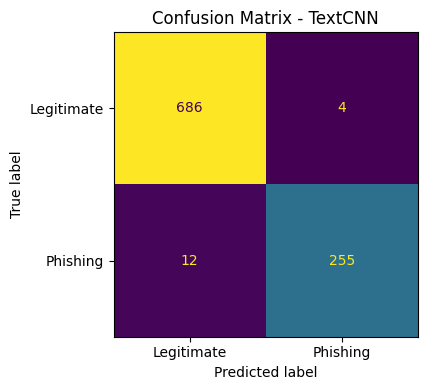

,Model,Dataset,Accuracy,Precision,Recall,F1,FPR,Inference_ms
0,TextCNN,Kaggle,0.9833,0.9846,0.9551,0.9696,0.0058,1.5106


In [8]:
criterion = nn.BCEWithLogitsLoss()

_, textcnn_acc, textcnn_prec, textcnn_rec, textcnn_f1, textcnn_fpr, labels_cnn, preds_cnn = evaluate(textcnn, test_loader, criterion, DEVICE)
textcnn_inference_ms = measure_inference_time(textcnn, test_loader, DEVICE)

print("TextCNN Classification Report:")
print(classification_report(labels_cnn, preds_cnn, target_names=["Legitimate (0)", "Phishing (1)"]))
print(f"  False Positive Rate (FPR): {textcnn_fpr:.4f}")
print(f"  Inference time (ms/email): {textcnn_inference_ms}")

results_textcnn = {
    "Model": "TextCNN",
    "Dataset": "Kaggle",
    "Accuracy": round(textcnn_acc, 4),
    "Precision": round(textcnn_prec, 4),
    "Recall": round(textcnn_rec, 4),
    "F1": round(textcnn_f1, 4),
    "FPR": round(textcnn_fpr, 4),
    "Inference_ms": textcnn_inference_ms,
}

cm_cnn = confusion_matrix(labels_cnn, preds_cnn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=["Legitimate", "Phishing"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False)
ax.set_title("Confusion Matrix - TextCNN")
plt.tight_layout()
plt.savefig(results_dir / "kaggle_cm_textcnn.png", dpi=150)
plt.show()

pd.DataFrame([results_textcnn])

## 8. Build BiLSTM Model

A Bidirectional LSTM is defined that reads each email sequence in both directions, capturing longer-range contextual patterns that a CNN may miss.

In [9]:
class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super(BiLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x, lengths):
        emb = self.embedding(x)
        packed = pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed)
        final = torch.cat([hidden[-2], hidden[-1]], dim=1)
        final = self.dropout(final)
        return self.fc(final).squeeze(1)

bilstm = BiLSTM(len(vocab), EMBED_DIM, LSTM_HIDDEN, LSTM_LAYERS, DROPOUT).to(DEVICE)
display_bilstm_summary(bilstm)

Model: "bilstm_model"
+-----------------------+------------------+-----------+
| Layer (type)          | Output Shape     |   Param # |
+-----------------------+------------------+-----------+
| input_1 (InputLayer)  | (None, 200)      |         0 |
| embedding (Embedding) | (None, 200, 100) | 2,000,000 |
| bidirectional (LSTM)  | (None, 256)      |   630,784 |
| dropout (Dropout)     | (None, 256)      |         0 |
| dense (Dense)         | (None, 1)        |       257 |
+-----------------------+------------------+-----------+
Total params: 2,631,041
Trainable params: 2,631,041
Non-trainable params: 0


## 9. Train BiLSTM

The BiLSTM model is trained for the configured number of epochs using the same data split and evaluation utilities as TextCNN for fair comparison.

In [10]:
history_lstm = run_training("BiLSTM", bilstm, train_loader, val_loader, NUM_EPOCHS, LEARNING_RATE, DEVICE)

Epoch 1/10
41/41 [==============================] - 23s 562ms/step - accuracy: 0.7676 - loss: 0.4307 - val_accuracy: 0.9583 - val_loss: 0.2079
Epoch 2/10
41/41 [==============================] - 25s 614ms/step - accuracy: 0.9318 - loss: 0.1902 - val_accuracy: 0.9792 - val_loss: 0.0806
Epoch 3/10
41/41 [==============================] - 30s 736ms/step - accuracy: 0.9760 - loss: 0.0748 - val_accuracy: 0.9861 - val_loss: 0.0491
Epoch 4/10
41/41 [==============================] - 34s 817ms/step - accuracy: 0.9915 - loss: 0.0312 - val_accuracy: 0.9861 - val_loss: 0.0330
Epoch 5/10
41/41 [==============================] - 30s 719ms/step - accuracy: 0.9954 - loss: 0.0179 - val_accuracy: 0.9861 - val_loss: 0.0317
Epoch 6/10
41/41 [==============================] - 30s 728ms/step - accuracy: 0.9961 - loss: 0.0113 - val_accuracy: 0.9861 - val_loss: 0.0433
Epoch 7/10
41/41 [==============================] - 30s 730ms/step - accuracy: 1.0000 - loss: 0.0036 - val_accuracy: 0.9861 - val_loss: 0.0413

## 10. Evaluate BiLSTM

The trained BiLSTM is evaluated on the held-out test set. The classification report, confusion matrix figure, and metrics are saved.

BiLSTM Classification Report:
                precision    recall  f1-score   support

Legitimate (0)       0.99      0.97      0.98       690
  Phishing (1)       0.92      0.97      0.94       267

      accuracy                           0.97       957
     macro avg       0.95      0.97      0.96       957
  weighted avg       0.97      0.97      0.97       957

  False Positive Rate (FPR): 0.0333
  Inference time (ms/email): 1.1693


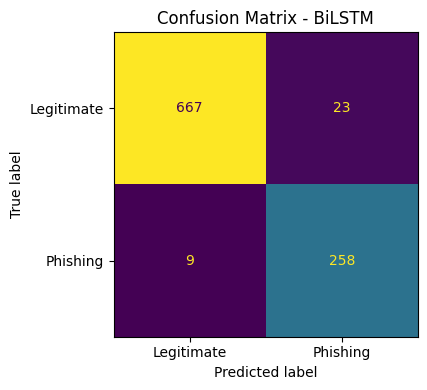

,Model,Dataset,Accuracy,Precision,Recall,F1,FPR,Inference_ms
0,BiLSTM,Kaggle,0.9666,0.9181,0.9663,0.9416,0.0333,1.1693


In [11]:
_, bilstm_acc, bilstm_prec, bilstm_rec, bilstm_f1, bilstm_fpr, labels_lstm, preds_lstm = evaluate(bilstm, test_loader, criterion, DEVICE)
bilstm_inference_ms = measure_inference_time(bilstm, test_loader, DEVICE)

print("BiLSTM Classification Report:")
print(classification_report(labels_lstm, preds_lstm, target_names=["Legitimate (0)", "Phishing (1)"]))
print(f"  False Positive Rate (FPR): {bilstm_fpr:.4f}")
print(f"  Inference time (ms/email): {bilstm_inference_ms}")

results_bilstm = {
    "Model": "BiLSTM",
    "Dataset": "Kaggle",
    "Accuracy": round(bilstm_acc, 4),
    "Precision": round(bilstm_prec, 4),
    "Recall": round(bilstm_rec, 4),
    "F1": round(bilstm_f1, 4),
    "FPR": round(bilstm_fpr, 4),
    "Inference_ms": bilstm_inference_ms,
}

cm_lstm = confusion_matrix(labels_lstm, preds_lstm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lstm, display_labels=["Legitimate", "Phishing"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False)
ax.set_title("Confusion Matrix - BiLSTM")
plt.tight_layout()
plt.savefig(results_dir / "kaggle_cm_bilstm.png", dpi=150)
plt.show()

pd.DataFrame([results_bilstm])

## 11. Training Curves

The training and validation loss and accuracy over epochs are plotted for both models to visualise learning behaviour and check for overfitting.

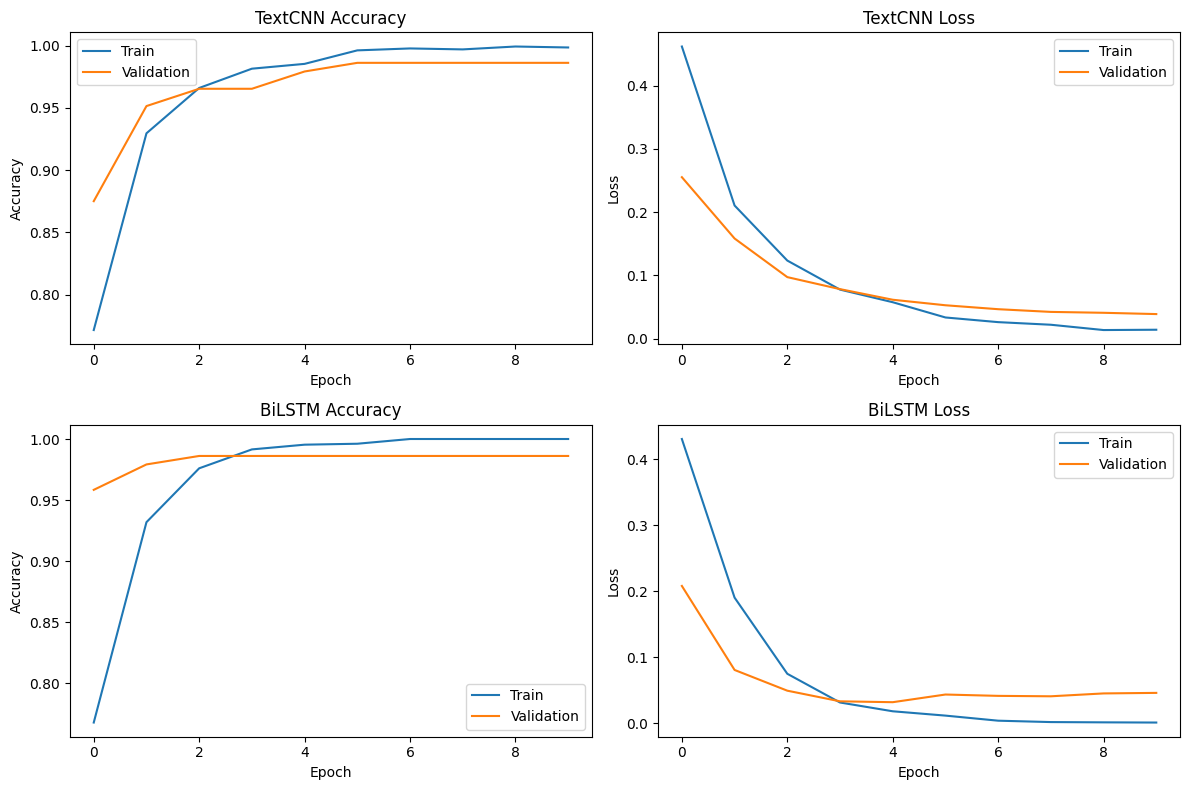

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(history_cnn["train_acc"], label="Train")
axes[0, 0].plot(history_cnn["val_acc"], label="Validation")
axes[0, 0].set_title("TextCNN Accuracy")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].legend()

axes[0, 1].plot(history_cnn["train_loss"], label="Train")
axes[0, 1].plot(history_cnn["val_loss"], label="Validation")
axes[0, 1].set_title("TextCNN Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()

axes[1, 0].plot(history_lstm["train_acc"], label="Train")
axes[1, 0].plot(history_lstm["val_acc"], label="Validation")
axes[1, 0].set_title("BiLSTM Accuracy")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].legend()

axes[1, 1].plot(history_lstm["train_loss"], label="Train")
axes[1, 1].plot(history_lstm["val_loss"], label="Validation")
axes[1, 1].set_title("BiLSTM Loss")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Loss")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(results_dir / "kaggle_dl_training_curves.png", dpi=150)
plt.show()

## 12. Save Results

Final metrics for both models are saved to a CSV file in the results folder, consistent with the output format of `kaggle_dl_results.csv`.

In [13]:
results_df = pd.DataFrame([results_textcnn, results_bilstm])
csv_path = results_dir / "kaggle_dl_results.csv"
results_df.to_csv(csv_path, index=False)

print(f"Results saved to {csv_path}")
results_df

Results saved to ../results/kaggle_dl_results.csv


,Model,Dataset,Accuracy,Precision,Recall,F1,FPR,Inference_ms
0,TextCNN,Kaggle,0.9833,0.9846,0.9551,0.9696,0.0058,1.5106
1,BiLSTM,Kaggle,0.9666,0.9181,0.9663,0.9416,0.0333,1.1693


## 13. Results Summary

The evaluation metrics for both models are compiled into a single CSV file matching the classical baseline schema for direct comparison.

In [14]:
summary_rows = []

for name, y_pred, inference_ms in [
    ("TextCNN", preds_cnn, textcnn_inference_ms),
    ("BiLSTM", preds_lstm, bilstm_inference_ms),
]:
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    summary_rows.append({
        "dataset": "Kaggle",
        "model": name,
        "accuracy": round(accuracy_score(y_test, y_pred), 6),
        "precision": round(precision_score(y_test, y_pred, pos_label=1), 6),
        "recall": round(recall_score(y_test, y_pred, pos_label=1), 6),
        "f1": round(f1_score(y_test, y_pred, pos_label=1), 6),
        "false_positive_rate": round(fpr, 6),
        "inference_time_ms_per_email": inference_ms,
        "train_rows": len(y_train),
        "test_rows": len(y_test),
        "vocab_size": len(vocab),
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string())

summary_path = results_dir / "kaggle_dl_baseline_results.csv"
summary_df.to_csv(summary_path, index=False)
print(f"\nResults saved to {summary_path}")

  dataset    model  accuracy  precision    recall        f1  false_positive_rate  inference_time_ms_per_email  train_rows  test_rows  vocab_size
0  Kaggle  TextCNN  0.983281   0.984556  0.955056  0.969582             0.005797                       1.5106        1435        957       20000
1  Kaggle   BiLSTM  0.966562   0.918149  0.966292  0.941606             0.033333                       1.1693        1435        957       20000

Results saved to ../results/kaggle_dl_baseline_results.csv
